# Correlations

In [42]:
import pickle
import torch
import pandas as pd
import numpy as np

from scipy.stats import pearsonr

import matplotlib.pyplot as plt
import seaborn as sns

## Read in data

In [2]:
# Infectivity
mutation_file = 'results/mutation_infectivity_effects.csv'
infectivity = pd.read_csv(mutation_file)

In [5]:
# Neutralization
neutralization_file = 'results/Pooled Mutation Effect/mutation_neutralization_effects_cross_pool.csv'
neutralization = pd.read_csv(neutralization_file)
# neutralization = neutralization.rename(columns={'Mean': 'Mean - Log', 'Std':'Std - Log'})
# neutralization['Mean'] = neutralization['Mean - Log'].apply(np.exp)

In [6]:
# PyR0
pyro_file = 'data/PyR0/2023-09-19/mutations.tsv'
pyro = pd.read_csv(pyro_file, sep='\t', usecols=['mutation', 'R / R_A', 'R / R_A 95% ci lower', 'R / R_A 95% ci upper']).rename(columns={'mutation':'Mutation'})
pyro = pyro[pyro['Mutation'].str.startswith('S:')]
pyro['Mutation'] = pyro['Mutation'].apply(lambda x: x[2:])

In [7]:
# BVAS
bvas_file = 'data/BVAS/2023-09-20/allele_summary.csv'
bvas = pd.read_csv(bvas_file).rename(columns={'Unnamed: 0':'Mutation'}).drop(columns='Rank')
bvas = bvas[bvas['Mutation'].str.startswith('S:')]
bvas['Mutation'] = bvas['Mutation'].apply(lambda x: x[2:])

In [8]:
# Join
df = pd.DataFrame()
df = pd.merge(infectivity, neutralization, on='Mutation', suffixes=[' Infectivity', ' Neutralization'])
df = pd.merge(df, pyro, on='Mutation', suffixes=['', ''])
df = pd.merge(df, bvas, on='Mutation', suffixes=['', ''])
df = df.rename(columns={'R / R_A':'R / R_A (PyR0)', 'PIP':'PIP (BVAS)', 'Beta':'Beta (BVAS)'})
df

,Mutation,Mean Infectivity,Std Infectivity,Mean Neutralization,Std Neutralization,N,R / R_A (PyR0),R / R_A 95% ci lower,R / R_A 95% ci upper,PIP (BVAS),Beta (BVAS),BetaStd,ConditionalBeta,ConditionalBetaStd
0,V213G,0.463969,0.219508,0.009097,0.030155,21.0,1.057070,1.057030,1.05711,0.012438,-0.000046,0.009131,-0.006068,0.105169
1,Q493R,0.165031,0.099108,-0.189301,0.053755,1447.0,0.962116,0.961992,0.96224,1.000000,-0.532805,0.071332,-0.532805,0.071332
2,R346T,0.014395,0.087335,-0.226299,0.054392,23.0,1.167680,1.167250,1.16812,1.000000,0.379058,0.024746,0.379058,0.024746
3,R346K,-0.043522,0.217860,-0.061447,0.054983,1424.0,1.098130,1.098090,1.09818,1.000000,0.335846,0.023385,0.335846,0.023385
4,T19R,-0.126380,0.200306,-0.072723,0.045928,23.0,1.007000,1.006960,1.00704,0.900275,0.275853,0.134424,0.309105,0.099849
5,T76I,-0.455108,0.141412,-0.077259,0.026850,950.0,1.031250,1.031040,1.03146,1.000000,-0.168680,0.025677,-0.168680,0.025677
6,L452R,-0.696611,0.122566,-0.453853,0.101568,127.0,1.176720,1.176530,1.17691,1.000000,0.510087,0.041544,0.510087,0.041544
7,G339D,-0.717093,0.153655,-0.193185,0.037261,312.0,1.054520,1.054440,1.05460,0.017432,0.000910,0.010515,0.054853,0.060890
8,T478K,-0.761305,0.242583,0.214983,0.018185,46.0,1.388530,1.385010,1.39205,0.007356,-0.000125,0.013750,-0.001110,0.040941


#### Quick correlation

In [9]:
df[['Mean Infectivity', 'Mean Neutralization', 'R / R_A (PyR0)', 'Beta (BVAS)', 'PIP (BVAS)']].corr()

,Mean Infectivity,Mean Neutralization,R / R_A (PyR0),Beta (BVAS),PIP (BVAS)
Mean Infectivity,1.000000,0.087525,-0.513301,-0.194205,0.164988
Mean Neutralization,0.087525,1.000000,0.340222,-0.318590,-0.535849
R / R_A (PyR0),-0.513301,0.340222,1.000000,0.363702,-0.353771
Beta (BVAS),-0.194205,-0.318590,0.363702,1.000000,0.194167
PIP (BVAS),0.164988,-0.535849,-0.353771,0.194167,1.000000


## Compare neutralization & infectivity with each other

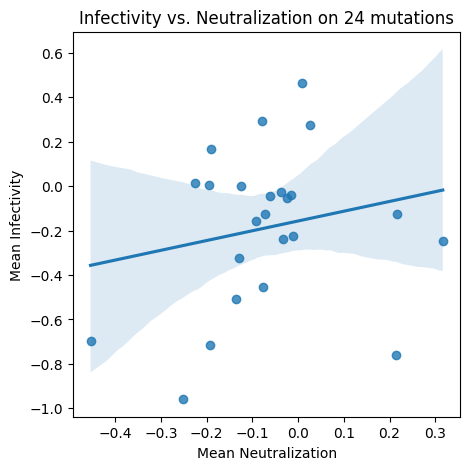

In [10]:
# Neutralization vs Infectivity
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Neutralization',
            y='Mean Infectivity',
            data=pd.merge(neutralization, infectivity, on='Mutation', suffixes = [' Neutralization', ' Infectivity']),
            ax=ax);

inf_muts = set(infectivity.Mutation)
neut_muts = set(neutralization.Mutation)

ax.set_title('Infectivity vs. Neutralization on {} mutations'.format(len(inf_muts&neut_muts)));

## Infectivity & Neutralization vs Predicted Growth Rate (PyR0 and BVAS)

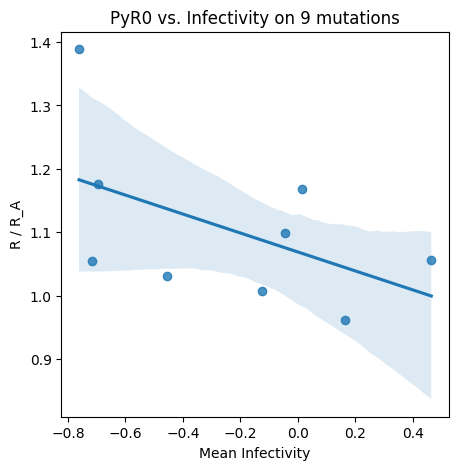

In [11]:
# Infectivity vs PyR0
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Infectivity',
            y='R / R_A',
            data=pd.merge(infectivity, pyro, on='Mutation').rename(columns={'Mean':'Mean Infectivity'}),
            ax=ax);

pyro_muts = set(pyro.Mutation)
inf_muts = set(infectivity.Mutation)

ax.set_title('PyR0 vs. Infectivity on {} mutations'.format(len(pyro_muts&inf_muts)));

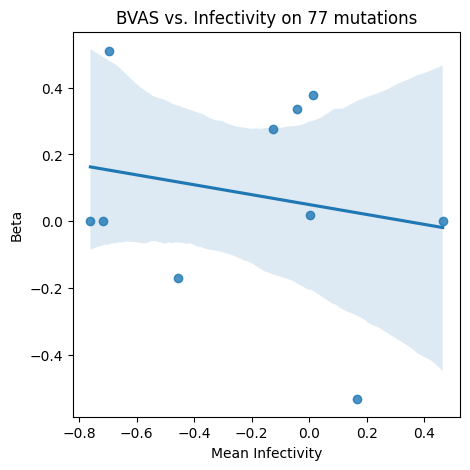

In [12]:
# Infectivity vs BVAS Beta
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Infectivity',
            y='Beta',
            data=pd.merge(infectivity, bvas, on='Mutation').rename(columns={'Mean':'Mean Infectivity'}),
            ax=ax);

bvas_muts = set(bvas.Mutation)
neut_muts = set(neutralization.Mutation)

ax.set_title('BVAS vs. Infectivity on {} mutations'.format(len(bvas_muts&neut_muts)));

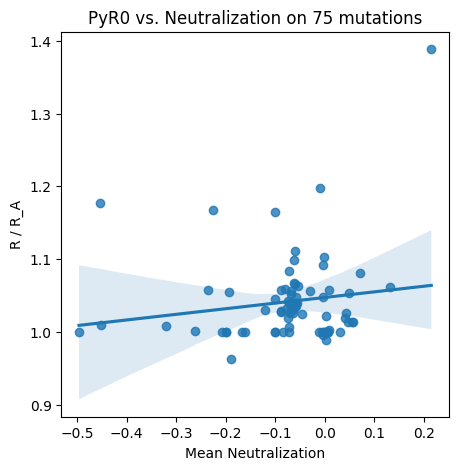

In [13]:
# Neutralization vs PyR0
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Neutralization',
            y='R / R_A',
            data=pd.merge(neutralization, pyro, on='Mutation').rename(columns={'Mean':'Mean Neutralization'}),
            ax=ax);

pyro_muts = set(pyro.Mutation)
neut_muts = set(neutralization.Mutation)

ax.set_title('PyR0 vs. Neutralization on {} mutations'.format(len(pyro_muts&neut_muts)));

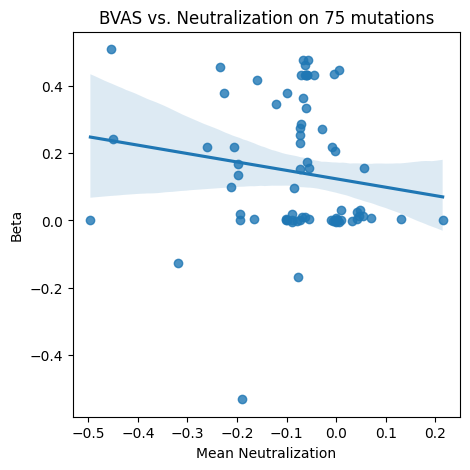

In [14]:
# Neutralization vs BVAS
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Neutralization',
            y='Beta',
            data=pd.merge(neutralization, bvas, on='Mutation').rename(columns={'Mean':'Mean Neutralization'}),
            ax=ax);

bvas_muts = set(bvas.Mutation)
neut_muts = set(neutralization.Mutation)

ax.set_title('BVAS vs. Neutralization on {} mutations'.format(len(pyro_muts&neut_muts)));

## Explore With DMS
DMS data from the paper [Deep Mutational Scanning of SARS-CoV-2 Receptor Binding Domain Reveals Constraints on Folding and ACE2 Binding](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7418704/). DMS for expression and ACE2 binding of the RBD can be found on [github](https://github.com/jbloomlab/SARS-CoV-2-RBD_DMS/blob/master/results/single_mut_effects/single_mut_effects.csv). For this repository, the data have been downloaded to the `data` subdirectory of this repository.

In [15]:
# Read in DMS data
filename = 'data/Bloom/single_mut_effects.txt'
columns = {#'site_SARS2':'position', 
           'mutation':'Mutation', 
           'bind_avg':'ACE2 Binding', 
           'expr_avg':'Expression'}
dms = pd.read_csv(filename, usecols=columns.keys()).rename(columns=columns)

In [16]:
df = pd.merge(neutralization, infectivity, on='Mutation', suffixes = [' Neutralization', ' Infectivity'])
df = pd.merge(df, dms, on='Mutation')
df[['Mean Neutralization', 'Mean Infectivity', 'ACE2 Binding', 'Expression']].corr()

,Mean Neutralization,Mean Infectivity,ACE2 Binding,Expression
Mean Neutralization,1.000000,0.206284,-0.399504,0.190722
Mean Infectivity,0.206284,1.000000,-0.155014,-0.143499
ACE2 Binding,-0.399504,-0.155014,1.000000,-0.196268
Expression,0.190722,-0.143499,-0.196268,1.000000


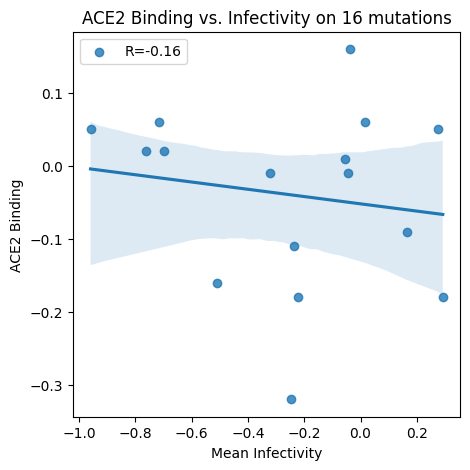

In [17]:
# Infectivity vs ACE2 Binding
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Infectivity',
            y='ACE2 Binding',
            data=pd.merge(infectivity, dms, on='Mutation').rename(columns={'Mean':'Mean Infectivity'}),
            label='R={:.2f}'.format(pd.merge(infectivity, dms, on='Mutation')[['Mean','ACE2 Binding']].corr().values[0,1]),
            ax=ax);
ax.legend()

ace_muts = set(dms.Mutation)
inf_muts = set(infectivity.Mutation)

ax.set_title('ACE2 Binding vs. Infectivity on {} mutations'.format(len(ace_muts&inf_muts)));

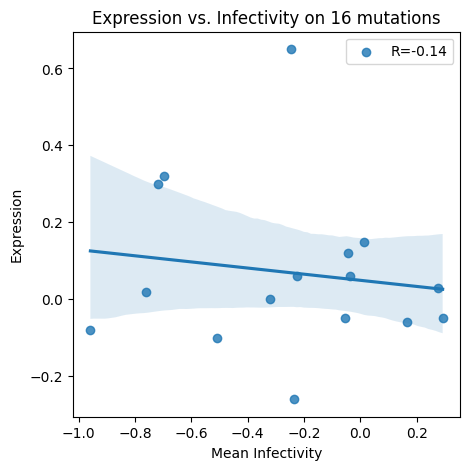

In [18]:
# Infectivity vs Expression
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Infectivity',
            y='Expression',
            data=pd.merge(infectivity, dms, on='Mutation').rename(columns={'Mean':'Mean Infectivity'}),
            label='R={:.2f}'.format(pd.merge(infectivity, dms, on='Mutation')[['Mean','Expression']].corr().values[0,1]),
            ax=ax);
ax.legend()

exp_muts = set(dms.Mutation)
inf_muts = set(infectivity.Mutation)

ax.set_title('Expression vs. Infectivity on {} mutations'.format(len(exp_muts&inf_muts)));

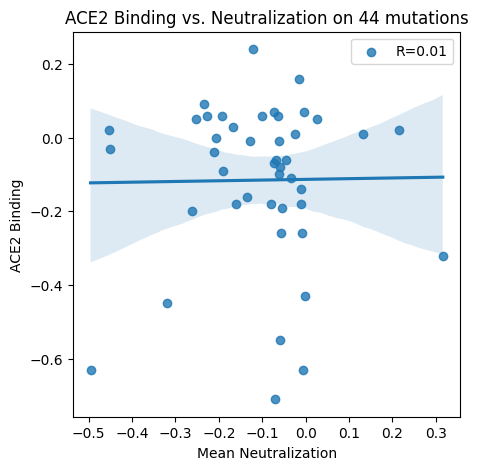

In [19]:
# Neutralization vs ACE2 Binding
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Neutralization',
            y='ACE2 Binding',
            data=pd.merge(neutralization, dms, on='Mutation').rename(columns={'Mean':'Mean Neutralization'}),
            label='R={:.2f}'.format(pd.merge(neutralization, dms, on='Mutation')[['Mean','ACE2 Binding']].corr().values[0,1]),
            ax=ax);
ax.legend()

ace_muts = set(dms.Mutation)
neut_muts = set(neutralization.Mutation)

ax.set_title('ACE2 Binding vs. Neutralization on {} mutations'.format(len(ace_muts&neut_muts)));

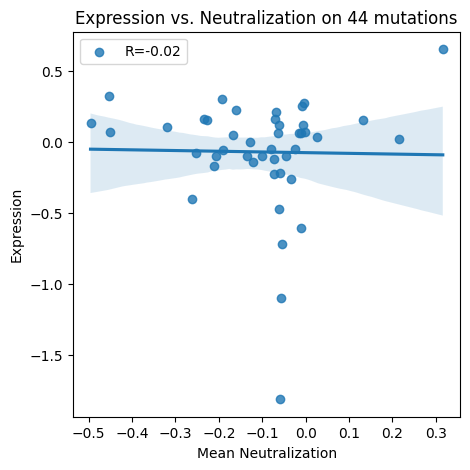

In [20]:
# Neutralization vs Expression
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Neutralization',
            y='Expression',
            data=pd.merge(neutralization, dms, on='Mutation').rename(columns={'Mean':'Mean Neutralization'}),
            label='R={:.2f}'.format(pd.merge(neutralization, dms, on='Mutation')[['Mean','Expression']].corr().values[0,1]),
            ax=ax);
ax.legend()

exp_muts = set(dms.Mutation)
neut_muts = set(neutralization.Mutation)

ax.set_title('Expression vs. Neutralization on {} mutations'.format(len(exp_muts&neut_muts)));

## Compare to Bloom Fitness

In [21]:
filename = 'data/Bloom/aamut_fitness_all.csv'
columns = {'gene':'Gene',
           'aa_site': 'Position',
           'aa_mutation': 'Mutation',
           'delta_fitness': 'Bloom Fitness'}
bloom = pd.read_csv(filename, usecols=columns.keys()).rename(columns=columns)
bloom = bloom[bloom['Gene'] == 'S'].sort_values(by='Position').reset_index(drop=True)

In [22]:
df = pd.merge(neutralization, infectivity, on='Mutation', suffixes = [' Neutralization', ' Infectivity'])
df = pd.merge(df, bloom, on='Mutation')
df[['Mean Neutralization', 'Mean Infectivity', 'Bloom Fitness']].corr()

,Mean Neutralization,Mean Infectivity,Bloom Fitness
Mean Neutralization,1.000000,0.154227,-0.478933
Mean Infectivity,0.154227,1.000000,-0.195810
Bloom Fitness,-0.478933,-0.195810,1.000000


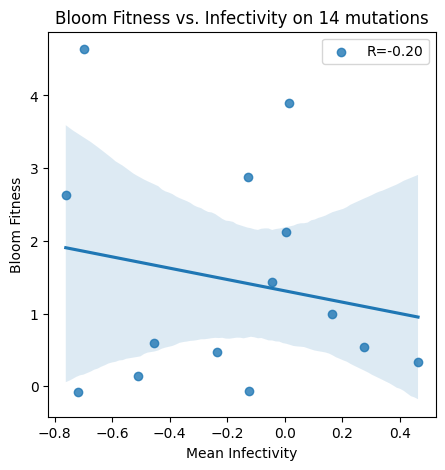

In [23]:
# Infectivity vs Bloom Fitness
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Infectivity',
            y='Bloom Fitness',
            data=pd.merge(infectivity, bloom, on='Mutation').rename(columns={'Mean':'Mean Infectivity'}),
            label='R={:.2f}'.format(pd.merge(infectivity, bloom, on='Mutation')[['Mean','Bloom Fitness']].corr().values[0,1]),
            ax=ax);
ax.legend()

bloom_muts = set(bloom.Mutation)
inf_muts = set(infectivity.Mutation)

ax.set_title('Bloom Fitness vs. Infectivity on {} mutations'.format(len(bloom_muts&inf_muts)));

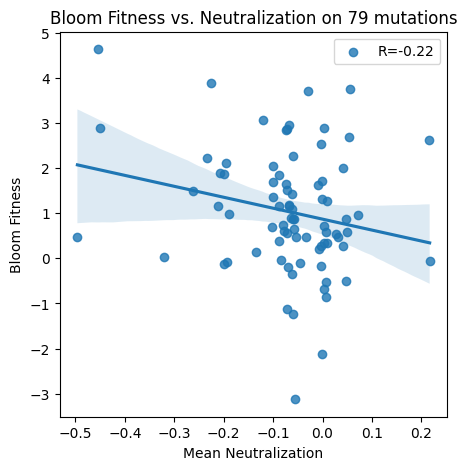

In [24]:
# Neutralization vs Bloom Fitness
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Neutralization',
            y='Bloom Fitness',
            data=pd.merge(neutralization, bloom, on='Mutation').rename(columns={'Mean':'Mean Neutralization'}),
            label='R={:.2f}'.format(pd.merge(neutralization, bloom, on='Mutation')[['Mean','Bloom Fitness']].corr().values[0,1]),
            ax=ax);
ax.legend()

bloom_muts = set(bloom.Mutation)
neut_muts = set(neutralization.Mutation)

ax.set_title('Bloom Fitness vs. Neutralization on {} mutations'.format(len(bloom_muts&neut_muts)));

## Compare to EVE and EVEscape

In [25]:
filename = 'data/EVEscape/spike_evescape_predictions.csv'
columns = {'i':'Position', 
           'wt':'wt',
           'mut':'mut',
           'evescape':'EVEscape',
           'eve':'EVE'}
evescape = pd.read_csv(filename, usecols=columns.keys()).rename(columns=columns).sort_values(by='Position').reset_index(drop=True)
evescape['Mutation'] = evescape['wt'].astype(str) + evescape['Position'].astype(str) + evescape['mut'].astype(str)

In [26]:
df = pd.merge(neutralization, infectivity, on='Mutation', suffixes = [' Neutralization', ' Infectivity'])
df = pd.merge(df, evescape, on='Mutation')
df[['Mean Neutralization', 'Mean Infectivity', 'EVEscape', 'EVE']].corr()

,Mean Neutralization,Mean Infectivity,EVEscape,EVE
Mean Neutralization,1.000000,0.201238,0.024678,0.227566
Mean Infectivity,0.201238,1.000000,-0.337245,-0.245972
EVEscape,0.024678,-0.337245,1.000000,0.505991
EVE,0.227566,-0.245972,0.505991,1.000000


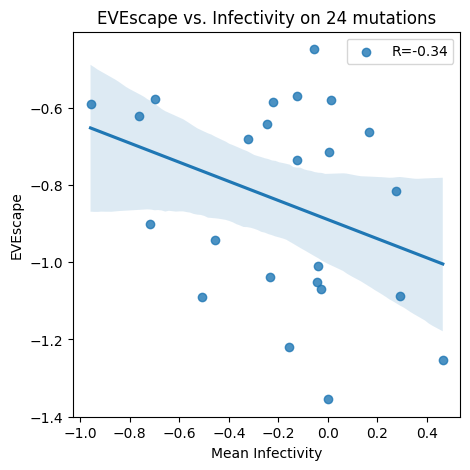

In [27]:
# Infectivity vs EVEscape
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Infectivity',
            y='EVEscape',
            data=pd.merge(infectivity, evescape, on='Mutation').rename(columns={'Mean':'Mean Infectivity'}),
            label='R={:.2f}'.format(pd.merge(infectivity, evescape, on='Mutation')[['Mean','EVEscape']].corr().values[0,1]),
            ax=ax);
ax.legend()

eve_muts = set(evescape.Mutation)
inf_muts = set(infectivity.Mutation)

ax.set_title('EVEscape vs. Infectivity on {} mutations'.format(len(eve_muts&inf_muts)));

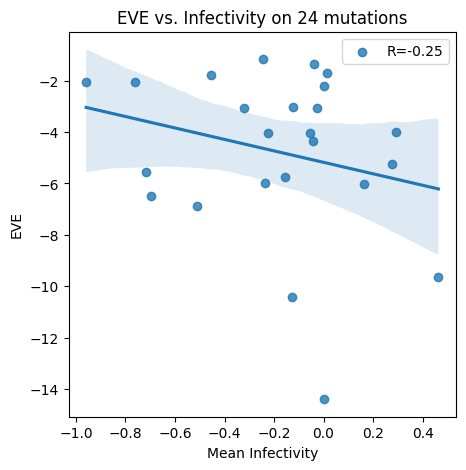

In [28]:
# Infectivity vs EVE
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Infectivity',
            y='EVE',
            data=pd.merge(infectivity, evescape, on='Mutation').rename(columns={'Mean':'Mean Infectivity'}),
            label='R={:.2f}'.format(pd.merge(infectivity, evescape, on='Mutation')[['Mean','EVE']].corr().values[0,1]),
            ax=ax);
ax.legend()

eve_muts = set(evescape.Mutation)
inf_muts = set(infectivity.Mutation)

ax.set_title('EVE vs. Infectivity on {} mutations'.format(len(eve_muts&inf_muts)));

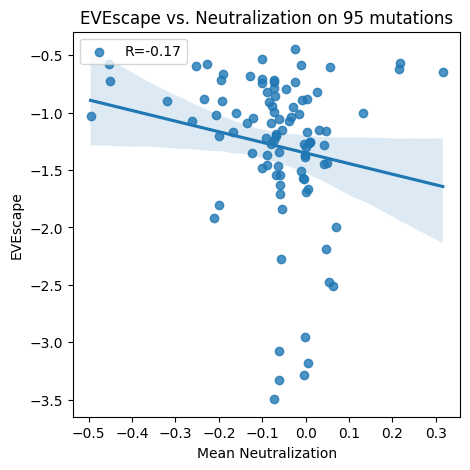

In [29]:
# Neutralization vs EVEscape
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Neutralization',
            y='EVEscape',
            data=pd.merge(neutralization, evescape, on='Mutation').rename(columns={'Mean':'Mean Neutralization'}),
            label='R={:.2f}'.format(pd.merge(neutralization, evescape, on='Mutation')[['Mean','EVEscape']].corr().values[0,1]),
            ax=ax);
ax.legend()

eve_muts = set(evescape.Mutation)
neut_muts = set(neutralization.Mutation)

ax.set_title('EVEscape vs. Neutralization on {} mutations'.format(len(eve_muts&neut_muts)));

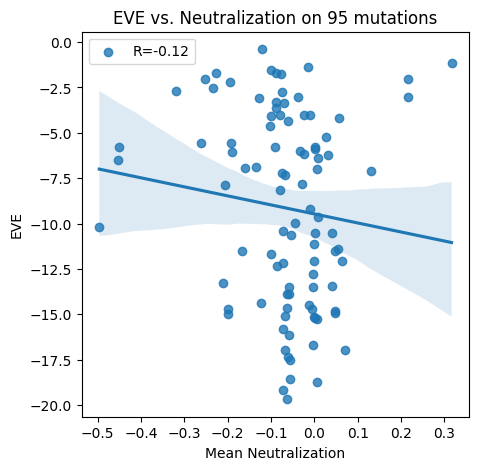

In [30]:
# Neutralization vs EVE
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Neutralization',
            y='EVE',
            data=pd.merge(neutralization, evescape, on='Mutation').rename(columns={'Mean':'Mean Neutralization'}),
            label='R={:.2f}'.format(pd.merge(neutralization, evescape, on='Mutation')[['Mean','EVE']].corr().values[0,1]),
            ax=ax);
ax.legend()

eve_muts = set(evescape.Mutation)
neut_muts = set(neutralization.Mutation)

ax.set_title('EVE vs. Neutralization on {} mutations'.format(len(eve_muts&neut_muts)));

## Compare to DMS - Escape

In [31]:
filename = 'data/EVEscape/spike_evescape_predictions.csv'
columns = {'i':'Position', 
           'wt':'wt',
           'mut':'mut',
           'max_escape_bloom':'Bloom - Max Escape',
           'max_escape_xie':'Xie - Max Escape'}
escape = pd.read_csv(filename, usecols=columns.keys()).rename(columns=columns).sort_values(by='Position').reset_index(drop=True)
escape['Mutation'] = escape['wt'].astype(str) + evescape['Position'].astype(str) + evescape['mut'].astype(str)

In [32]:
df = pd.merge(neutralization, infectivity, on='Mutation', suffixes = [' Neutralization', ' Infectivity'])
df = pd.merge(df, escape, on='Mutation')
df[['Mean Neutralization', 'Mean Infectivity', 'Bloom - Max Escape', 'Xie - Max Escape']].corr()

,Mean Neutralization,Mean Infectivity,Bloom - Max Escape,Xie - Max Escape
Mean Neutralization,1.000000,0.201238,-0.075203,0.099883
Mean Infectivity,0.201238,1.000000,0.437724,0.077013
Bloom - Max Escape,-0.075203,0.437724,1.000000,0.550205
Xie - Max Escape,0.099883,0.077013,0.550205,1.000000


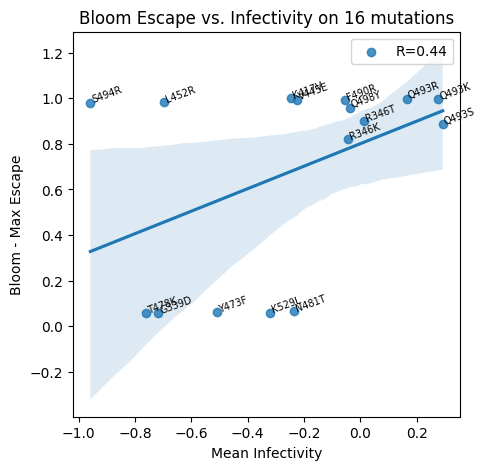

In [33]:
# Infectivity vs Bloom
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Infectivity',
            y='Bloom - Max Escape',
            data=pd.merge(infectivity, escape, on='Mutation').rename(columns={'Mean':'Mean Infectivity'}),
            label='R={:.2f}'.format(pd.merge(infectivity, escape, on='Mutation')[['Mean','Bloom - Max Escape']].corr().values[0,1]),
            # logistic=True,
            ax=ax);
ax.legend()

eve_muts = set(escape.dropna().Mutation)
inf_muts = set(infectivity.Mutation)

# Annotate muts
for mut in eve_muts&inf_muts:
    x = infectivity['Mean'][infectivity['Mutation']==mut].item()
    y = escape['Bloom - Max Escape'][escape['Mutation']==mut].item()
    if not pd.isna(x) and not pd.isna(y):
        ax.text(x, y, mut, rotation=20, fontsize=7)

ax.set_title('Bloom Escape vs. Infectivity on {} mutations'.format(len(eve_muts&inf_muts)));

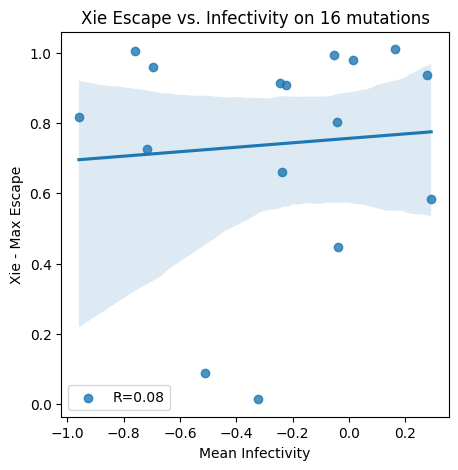

In [34]:
# Infectivity vs Xie
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Infectivity',
            y='Xie - Max Escape',
            data=pd.merge(infectivity, escape, on='Mutation').rename(columns={'Mean':'Mean Infectivity'}),
            label='R={:.2f}'.format(pd.merge(infectivity, escape, on='Mutation')[['Mean','Xie - Max Escape']].corr().values[0,1]),
            ax=ax);
ax.legend()

eve_muts = set(escape.dropna().Mutation)
inf_muts = set(infectivity.Mutation)

ax.set_title('Xie Escape vs. Infectivity on {} mutations'.format(len(eve_muts&inf_muts)));

PearsonRResult(statistic=-0.2605992421248414, pvalue=0.08754046200581314)


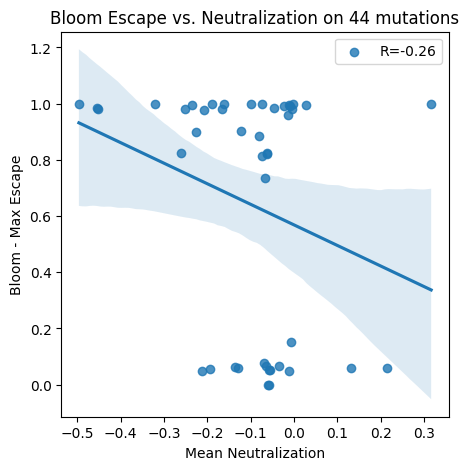

In [67]:
# Neutralization vs Bloom
data = pd.merge(neutralization, escape, on='Mutation').rename(columns={'Mean':'Mean Neutralization'})
# data['Clean'] = np.where((data['Std'] < 0.5) | (data['N'] > 700), 'Clean', 'Messy')
# data = data[data['Clean']=='Clean']
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Neutralization',
            y='Bloom - Max Escape',
            data=data,
            # scatter=False,
            # label='R={:.2f}'.format(pd.merge(neutralization, escape, on='Mutation')[['Mean','Bloom - Max Escape']].corr().values[0,1]),
            label='R={:.2f}'.format(data[['Mean Neutralization','Bloom - Max Escape']].corr().values[0,1]),
            # logistic=True,
            ax=ax);
# sns.scatterplot(x='Mean Neutralization',
#             y='Bloom - Max Escape',
#             data=data,
#             hue='Clean',
#             ax=ax);
ax.legend()

bloom_muts = set(escape.dropna().Mutation)
neut_muts = set(neutralization.Mutation)

ax.set_title('Bloom Escape vs. Neutralization on {} mutations'.format(len(bloom_muts&neut_muts)));
print(pearsonr(data[['Mean Neutralization','Bloom - Max Escape']].dropna()['Mean Neutralization'], data[['Mean Neutralization','Bloom - Max Escape']].dropna()['Bloom - Max Escape']))

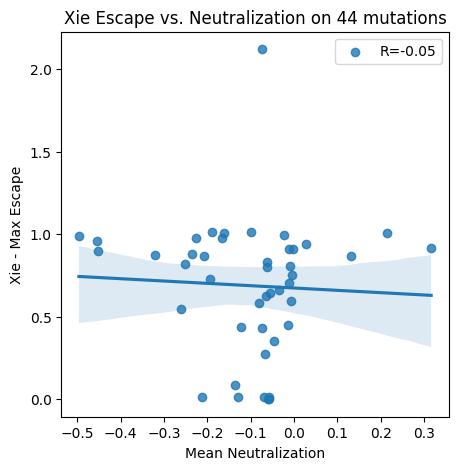

In [36]:
# Neutralization vs Xie
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Neutralization',
            y='Xie - Max Escape',
            data=pd.merge(neutralization, escape, on='Mutation').rename(columns={'Mean':'Mean Neutralization'}),
            label='R={:.2f}'.format(pd.merge(neutralization, escape, on='Mutation')[['Mean','Xie - Max Escape']].corr().values[0,1]),
            ax=ax);
ax.legend()

eve_muts = set(escape.dropna().Mutation)
neut_muts = set(neutralization.Mutation)

ax.set_title('Xie Escape vs. Neutralization on {} mutations'.format(len(eve_muts&neut_muts)));

In [50]:
# Bloom escape calculator
# calculator from https://github.com/jbloomlab/SARS2-RBD-escape-calc/blob/main/escapecalculator.py
from escapecalculator import EscapeCalculator
calc = EscapeCalculator()

PearsonRResult(statistic=0.025014253659528026, pvalue=0.8719562244017095)


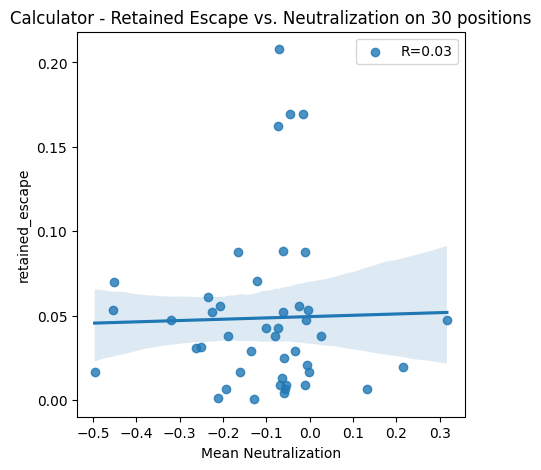

In [76]:
# Calculator vs Neutralization
neutralization['Mean Neutralization'] = neutralization['Mean']
neutralization['Position'] = neutralization['Mutation'].apply(lambda x: int(''.join([_ for _ in x if _.isdigit()])))
positions = neutralization['Position'].tolist()

calc_df = calc.escape_per_site([]).query('site in @positions').reset_index(drop=True)
calc_df = calc_df.rename(columns={'site':'Position'})

data = pd.merge(calc_df, neutralization, on='Position')

fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Neutralization',
            y='retained_escape',
            data=data,
            # scatter=False,
            # label='R={:.2f}'.format(pd.merge(neutralization, escape, on='Mutation')[['Mean','Bloom - Max Escape']].corr().values[0,1]),
            label='R={:.2f}'.format(data[['Mean Neutralization','retained_escape']].corr().values[0,1]),
            # logistic=True,
            ax=ax);
# sns.scatterplot(x='Mean Neutralization',
#             y='Bloom - Max Escape',
#             data=data,
#             hue='Clean',
#             ax=ax);
ax.legend()

calc_muts = set(calc_df.dropna().Position)
neut_muts = set(neutralization.Position)

ax.set_title('Calculator - Retained Escape vs. Neutralization on {} positions'.format(len(calc_muts&neut_muts)));
print(pearsonr(data[['Mean Neutralization','retained_escape']].dropna()['Mean Neutralization'], data[['Mean Neutralization','retained_escape']].dropna()['retained_escape']))                                                           
                                                              